In [3]:
import sys
import os

model_upgrading_path = os.path.join("..","src")
sys.path.append(model_upgrading_path)

In [58]:
#  moduel
from my_package.model import health_model
from my_package.data.select_dataset_all import get_all_dataframe_from_database

# basic
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# model
from sklearn.metrics import confusion_matrix

In [24]:
# 함수 
def classification_metrics(y_true, y_pred):
    """
    정확도, 정밀도, 재현율, F1 스코어와 함께 TP, TN, FP, FN의 개수를 출력하는 함수.
    
    Args:
    - y_true: list or numpy array, 실제 라벨 값
    - y_pred: list or numpy array, 예측 라벨 값
    
    Returns:
    - metrics: dict, 정확도, 정밀도, 재현율, F1 스코어 및 TP, TN, FP, FN 값들
    """
    # 혼동 행렬 구하기
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # 정확도 (Accuracy)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # 정밀도 (Precision)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    # 재현율 (Recall)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # F1 스코어
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # 결과 출력
    metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1_score,
        'True Positives (TP)': tp,
        'True Negatives (TN)': tn,
        'False Positives (FP)': fp,
        'False Negatives (FN)': fn
    }
    
    # 결과 프린트
    print(f"정확도 (Accuracy): {accuracy:.4f} ({tp + tn} / {tp + tn + fp + fn} 전체 예측)")
    print(f"정밀도 (Precision): {precision:.4f} ({tp} / {tp + fp} 양성 예측)")
    print(f"재현율 (Recall): {recall:.4f} ({tp} / {tp + fn} 실제 양성)")
    print(f"F1 스코어 (F1 Score): {f1_score:.4f} (2 * ({precision:.4f} * {recall:.4f}) / ({precision:.4f} + {recall:.4f}))")
    print(f"TP (True Positives): {tp}")
    print(f"TN (True Negatives): {tn}")
    print(f"FP (False Positives): {fp}")
    print(f"FN (False Negatives): {fn}")
    
    return metrics

In [21]:
def classification_metrics(y_true, y_pred):
    """
    정확도, 정밀도, 재현율, F1 스코어를 계산하는 함수.
    
    Args:
    - y_true: list or numpy array, 실제 라벨 값
    - y_pred: list or numpy array, 예측 라벨 값
    
    Returns:
    - metrics: dict, 정확도, 정밀도, 재현율, F1 스코어
    """
    # 혼동 행렬 구하기
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # 정확도 (Accuracy)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # 정밀도 (Precision)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    # 재현율 (Recall)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # F1 스코어
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # 결과 출력
    metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1_score,
        'True Positives (TP)': tp,
        'True Negatives (TN)': tn,
        'False Positives (FP)': fp,
        'False Negatives (FN)': fn
    }
    
    # 결과 프린트
    print(f"정확도 (Accuracy): {accuracy:.4f}")
    print(f"정밀도 (Precision): {precision:.4f} ({tp} / {tp + fp} 양성 예측)")
    print(f"재현율 (Recall): {recall:.4f} ({tp} / {tp + fn} 실제 양성)")
    print(f"F1 스코어 (F1 Score): {f1_score:.4f}")
    print(f"TP (True Positives): {tp}")
    print(f"TN (True Negatives): {tn}")
    print(f"FP (False Positives): {fp}")
    print(f"FN (False Negatives): {fn}")
    
    return metrics

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4297 entries, 0 to 5215
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   FTS_MEAN      4297 non-null   float64
 1   FTS_MAX       4297 non-null   float64
 2   DIFF_MEAN     4297 non-null   float64
 3   DIFF_MAX      4297 non-null   float64
 4   TREND_SCORE   4297 non-null   float64
 5   HEALTH_SCORE  4297 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 235.0 KB
Roots mean Squared Error (RMSE): 7.649488828484586
R^2 Score: 0.9250838795879315


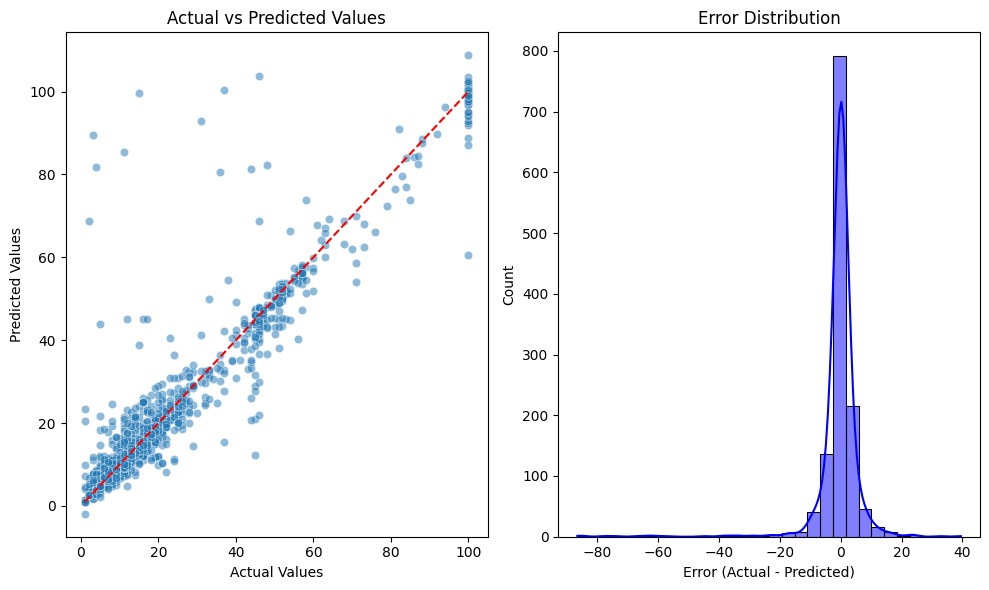

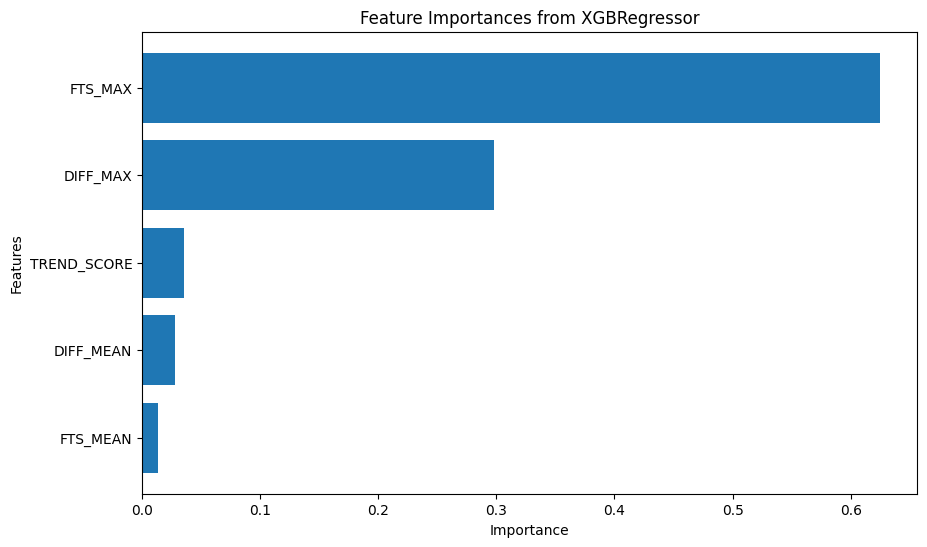

In [48]:
# goals: 데이터 생성 및 AI 학습

# 1. fts 클래스 사용 → 학습 데이터 생성
fts_data = health_model.FtsData()
selected_df=  fts_data.select_variable(['FTS_MEAN','FTS_MAX','DIFF_MEAN','DIFF_MAX','TREND_SCORE','HEALTH_SCORE'])

# 2. 데이터 정보
selected_df.info()

# 3. 학습
model, y_test, y_pred, X_train = health_model.train_xgboost_regression_model(selected_df)

# 4. 모델 결과 시각화
health_model.plot_regression_results(y_test, y_pred)

# 5. 모델 중요도 시각화
health_model.plot_feature_importance_xgboost(model,X_train)

# 6. 모델 저장 
# health_model.save_model_to_pickle(model, r"C:\Users\pc021\Desktop\dx_project\techross\health_learning_data\model_upgrading\src\my_package\model\fts_model")

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4284 entries, 0 to 5002
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CSU_MIN       4284 non-null   float64
 1   CSU_MEAN      4284 non-null   float64
 2   CSU_MAX       4284 non-null   float64
 3   DIFF_MIN      4284 non-null   float64
 4   DIFF_MEAN     4284 non-null   float64
 5   DIFF_MAX      4284 non-null   float64
 6   TREND_SCORE   4284 non-null   float64
 7   HEALTH_SCORE  4284 non-null   float64
dtypes: float64(8)
memory usage: 301.2 KB
Roots mean Squared Error (RMSE): 3.7159833335048567
R^2 Score: 0.9879106238447077


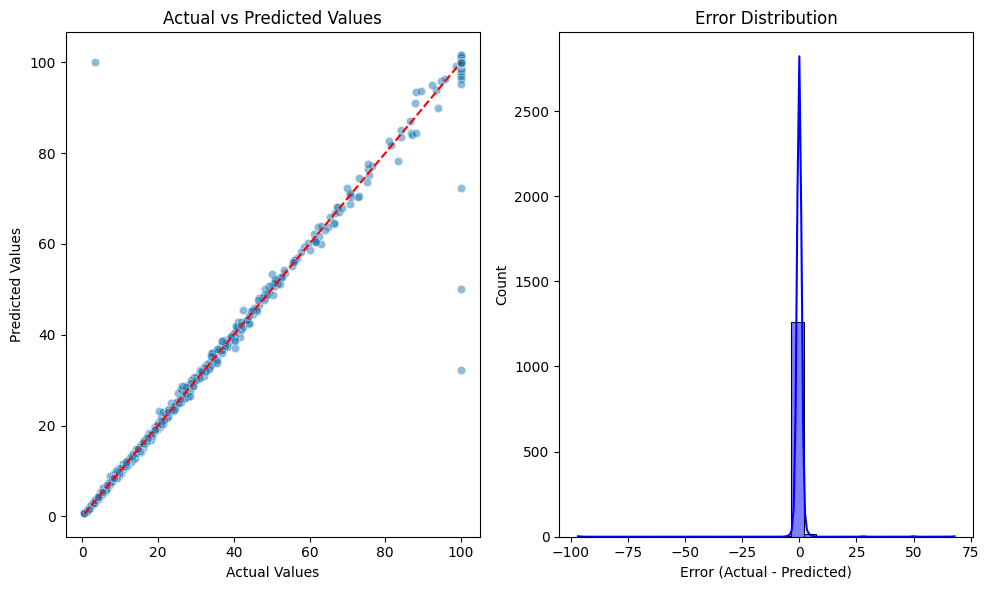

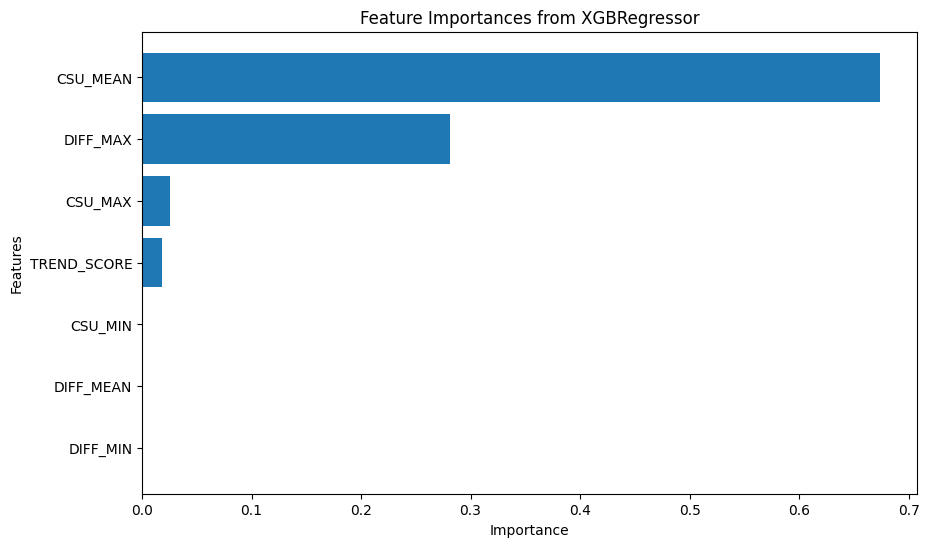

In [36]:
# goals: 데이터 생성 및 AI 학습

# 1. csu 클래스 사용 → 학습 데이터 생성
csu_data = health_model.CsuData()
selected_df=  csu_data.select_variable(['CSU_MIN','CSU_MEAN','CSU_MAX','DIFF_MIN','DIFF_MEAN','DIFF_MAX','TREND_SCORE','HEALTH_SCORE'])

# 2. 데이터 정보
selected_df.info()

# 3. 학습
model, y_test, y_pred, X_train = health_model.train_xgboost_regression_model(selected_df)

# 4. 모델 결과 시각화
health_model.plot_regression_results(y_test, y_pred)

# 5. 모델 중요도 시각화
health_model.plot_feature_importance_xgboost(model,X_train)

# 6. 모델 저장 
# health_model.save_model_to_pickle(model, r"C:\Users\pc021\Desktop\dx_project\techross\health_learning_data\model_upgrading\src\my_package\model\csu_model")

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3783 entries, 5 to 5000
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   STS_MIN       3783 non-null   float64
 1   STS_MEAN      3783 non-null   float64
 2   STS_MAX       3783 non-null   float64
 3   DIFF_MIN      3783 non-null   float64
 4   DIFF_MEAN     3783 non-null   float64
 5   DIFF_MAX      3783 non-null   float64
 6   TREND_SCORE   3783 non-null   float64
 7   HEALTH_SCORE  3783 non-null   float64
dtypes: float64(8)
memory usage: 266.0 KB
Roots mean Squared Error (RMSE): 3.588804726477251
R^2 Score: 0.972708123042618


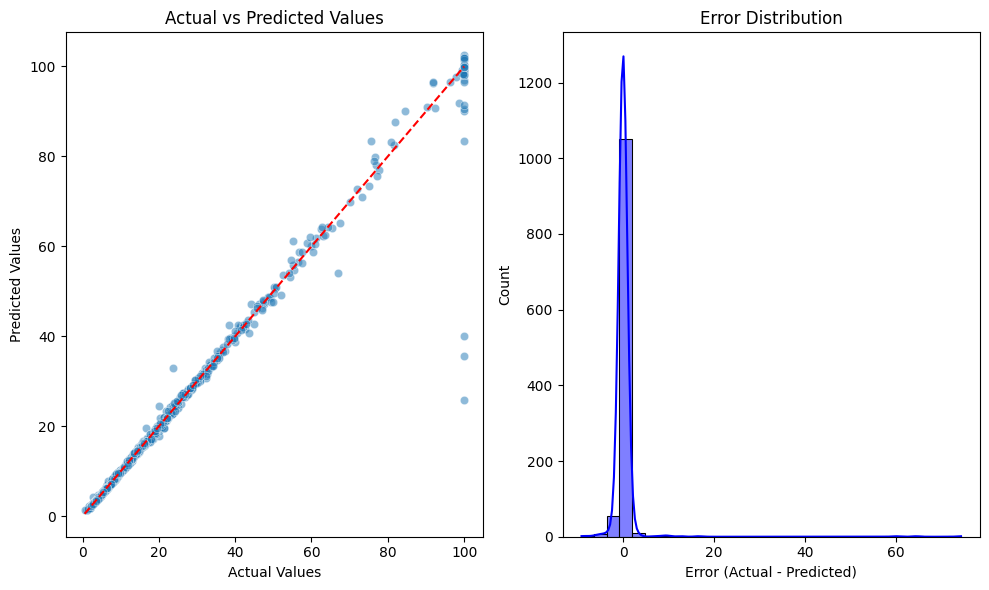

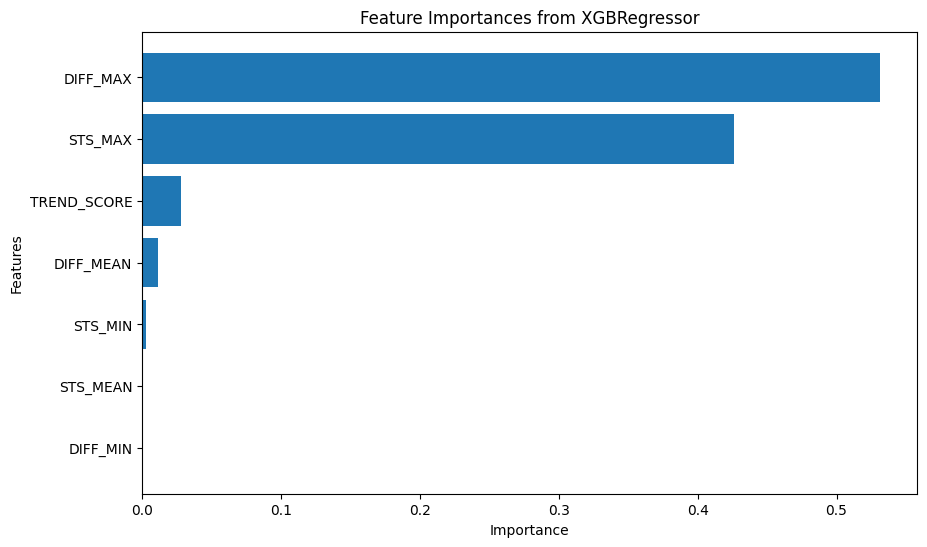

In [43]:
# goals: 데이터 생성 및 AI 학습

# 1. sts 클래스 사용 → 학습 데이터 생성
sts_data = health_model.StsData()
selected_df=  sts_data.select_variable(['STS_MIN','STS_MEAN','STS_MAX','DIFF_MIN','DIFF_MEAN','DIFF_MAX','TREND_SCORE','HEALTH_SCORE'])

# 2. 데이터 정보
selected_df.info()

# 3. 학습
model, y_test, y_pred, X_train = health_model.train_xgboost_regression_model(selected_df)

# 4. 모델 결과 시각화
health_model.plot_regression_results(y_test, y_pred)

# 5. 모델 중요도 시각화
health_model.plot_feature_importance_xgboost(model,X_train)

# 6. 모델 저장 
# health_model.save_model_to_pickle(model, r"C:\Users\pc021\Desktop\dx_project\techross\health_learning_data\model_upgrading\src\my_package\model\sts_model")

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4207 entries, 0 to 5000
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   FMU_MIN               4207 non-null   float64
 1   STANDARDIZE_FMU_MIN   4207 non-null   float64
 2   STANDARDIZE_FMU_MEAN  4207 non-null   float64
 3   STANDARDIZE_FMU_MAX   4207 non-null   float64
 4   HEALTH_SCORE          4207 non-null   float64
dtypes: float64(5)
memory usage: 197.2 KB
Roots mean Squared Error (RMSE): 4.8832334718196115
R^2 Score: 0.959560865529307


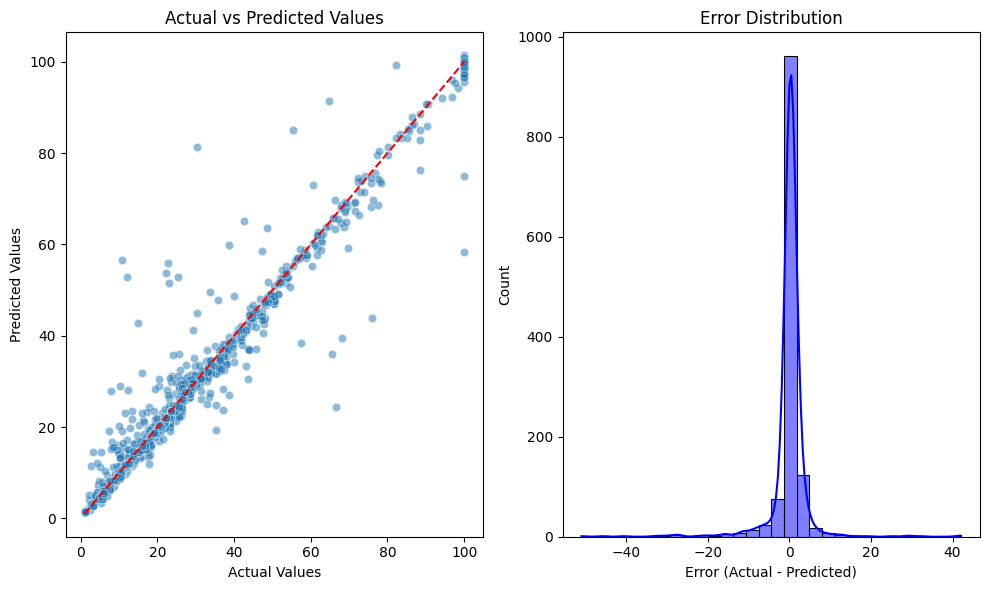

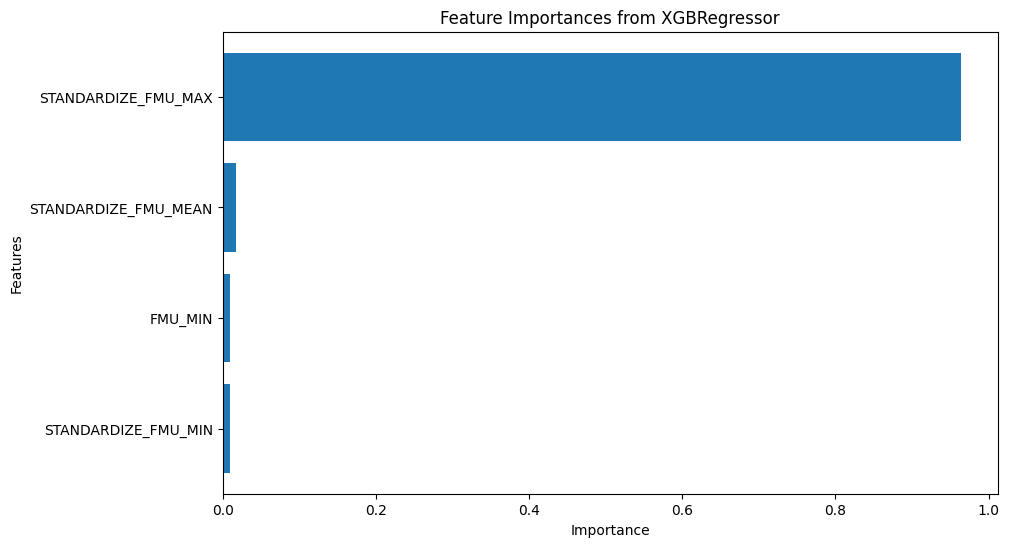

In [54]:
# goals: 데이터 생성 및 AI 학습

# 1. fmu 클래스 사용 → 학습 데이터 생성
fmu_data = health_model.FmuData()
selected_df=  fmu_data.select_variable(['FMU_MIN','STANDARDIZE_FMU_MIN','STANDARDIZE_FMU_MEAN','STANDARDIZE_FMU_MAX','HEALTH_SCORE'])

# 2. 데이터 정보
selected_df.info()

# 3. 학습
model, y_test, y_pred, X_train = health_model.train_xgboost_regression_model(selected_df)

# 4. 모델 결과 시각화
health_model.plot_regression_results(y_test, y_pred)

# 5. 모델 중요도 시각화
health_model.plot_feature_importance_xgboost(model,X_train)

# 6. 모델 저장 
# health_model.save_model_to_pickle(model, r"C:\Users\pc021\Desktop\dx_project\techross\health_learning_data\model_upgrading\src\my_package\model\fmu_model")

In [ ]:
# 결과 확인

# fmu: 0.6 (r^2) len(680) → 0.93 V
# csu: 0.89 (r^2) # len(data): 1699 → 0.81  1908(파생 변수 생성 후 ) 1908 → 0.99 V
# sts: 0.78 (r^2) len(680) → 0.96
# fts: 0.79 (r^2) 0.89로 증가 len(1277) → 0.92 V

# 처리 과정
# 데이터 정제 후 학습
# 파생 변수 추가 (health_score + trend_score = total_score, total_score + limit_score = HEALTH_SCORE)

In [66]:
anu = get_all_dataframe_from_database('tc_ai_anu_system_health','ecs')

anu = anu[['ANU','PRED_ANU']]
anu.columns = ['HEALTH_SCORE','PRED']

y_test = anu['HEALTH_SCORE']
y_pred = anu['PRED']

In [64]:
def categorize_variables(y_test,y_pred,col):
    category_dict = {'CSU': 97, 'STS':60, 'FTS':85, 'FMU':81, 'ECU':67,'ANU':33}
    
    limit = category_dict[col]
    
    data = y_test.to_frame()
    data['PRED'] = y_pred
    
    data['State'] = 0
    data.loc[data['HEALTH_SCORE']>limit,'State'] = 1
    
    data['PRED_State'] = 0
    data.loc[data['PRED']>limit,'PRED_State'] = 1
    
    return data

In [77]:
data

,HEALTH_SCORE,PRED,State,PRED_State
0,495.0,495.00,1,1
1,495.0,495.00,1,1
2,492.0,492.00,1,1
3,492.0,492.00,1,1
4,492.0,492.00,1,1
...,...,...,...,...
34206,156.0,53.67,1,1
34207,156.0,54.00,1,1
34208,156.0,53.67,1,1
34209,156.0,51.03,1,1


In [67]:
data = categorize_variables(y_test,y_pred,'ANU')

classification_metrics(data['State'],data['PRED_State'])

정확도 (Accuracy): 0.9949 (34038 / 34211 전체 예측)
정밀도 (Precision): 0.9943 (25646 / 25792 양성 예측)
재현율 (Recall): 0.9989 (25646 / 25673 실제 양성)
F1 스코어 (F1 Score): 0.9966 (2 * (0.9943 * 0.9989) / (0.9943 + 0.9989))
TP (True Positives): 25646
TN (True Negatives): 8392
FP (False Positives): 146
FN (False Negatives): 27


{'Accuracy': 0.9949431469410424,
 'Precision': 0.9943393300248139,
 'Recall': 0.9989483114556148,
 'F1 Score': 0.9966384921791508,
 'True Positives (TP)': 25646,
 'True Negatives (TN)': 8392,
 'False Positives (FP)': 146,
 'False Negatives (FN)': 27}

In [76]:
24500/25673  

0.9543099754606006